In [109]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
video_json_path = r"dataset\Anti-UAV-RGBT\test\20190925_111757_1_1\visible.json"  

with open(video_json_path) as f:
    data = json.load(f)

print(json.dumps(data, indent=4))  

{
    "exist": [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
    

In [ ]:
dataset_path = "dataset\Anti-UAV-RGBT"

records = []

def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    cap.release()
    return fps, frames, width, height


# Loop over splits (train, val, test)
for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if file.endswith("visible.mp4"):
                video_path = os.path.join(folder_path, file)
                json_path = video_path.replace("visible.mp4", "visible.json")
                
                if not os.path.exists(json_path):
                    continue

                fps, total_frames, w, h = get_video_info(video_path)

                with open(json_path) as f:
                    data = json.load(f)

                for frame_id, (bbox, exist) in enumerate(zip(data["gt_rect"], data["exist"])):
                    if exist == 1:  
                        records.append({
                            "split": split,
                            "folder": folder,
                            "video": file,
                            "video_path": os.path.abspath(video_path),                            
                            "fps": fps,
                            "total_frames": total_frames,
                            "width": w,
                            "height": h,
                            "frame_id": frame_id,
                            "bbox": bbox,  # [x, y, w, h]
                            "category": "default_class"  
                        })

df = pd.DataFrame(records)


<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Gur Levy\AppData\Local\Temp\ipykernel_23544\2154927805.py:1: SyntaxWarning: invalid escape sequence '\A'
  dataset_path = "dataset\Anti-UAV-RGBT"


In [112]:
print(len(df))

280218


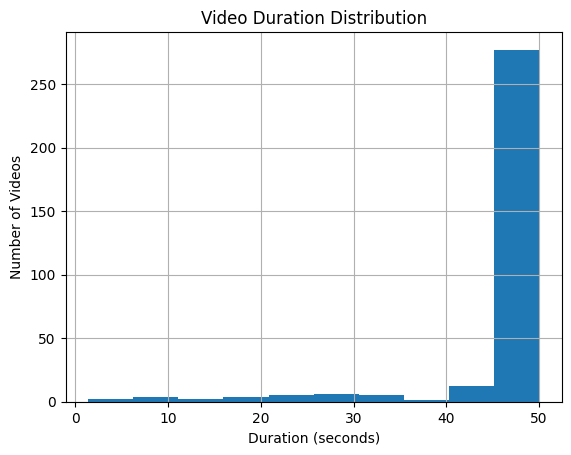

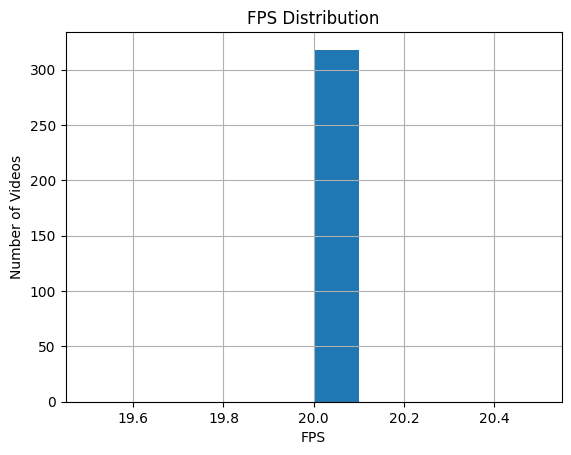

In [124]:
video_df = df.groupby("video_path").first().reset_index()

# Calculate video duration
video_df["duration"] = video_df["total_frames"] / video_df["fps"]

# Plot video duration distribution
video_df["duration"].hist()
plt.title("Video Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Videos")
plt.show()

# Plot FPS distribution
video_df["fps"].hist()
plt.title("FPS Distribution")
plt.xlabel("FPS")
plt.ylabel("Number of Videos")
plt.show()

In [115]:
print(len(video_df))
print(df["video"].nunique())
print(df["video_id"].nunique())

318
1
318


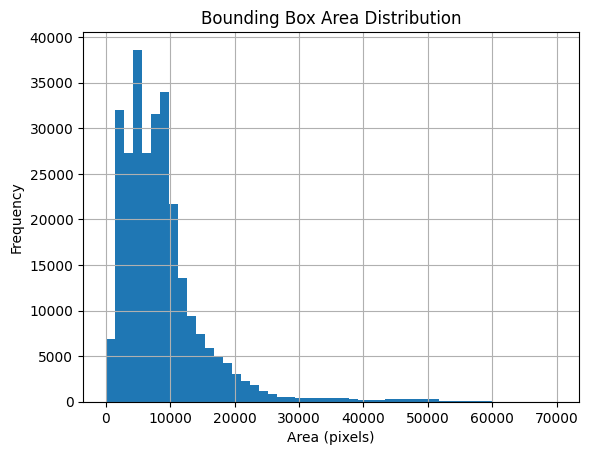

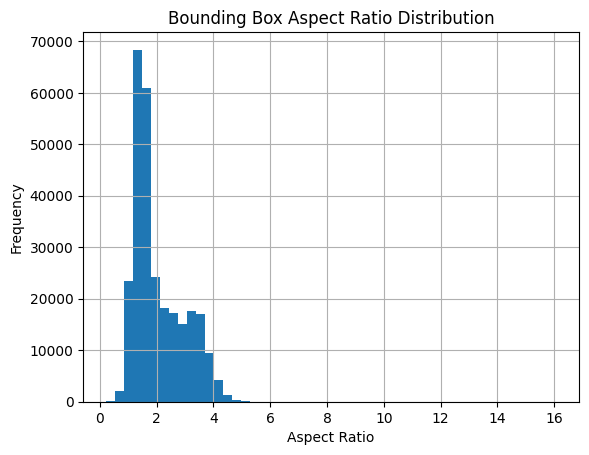

In [116]:
# Calculate bounding box width, height, area, and aspect ratio
df["bbox_w"] = df["bbox"].apply(lambda x: x[2])
df["bbox_h"] = df["bbox"].apply(lambda x: x[3])
df["area"] = df["bbox_w"] * df["bbox_h"]
df["aspect_ratio"] = df["bbox_w"] / df["bbox_h"]

# Plot Bounding Box Area Distribution
df["area"].hist(bins=50)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Area (pixels)")
plt.ylabel("Frequency")
plt.show()

# Plot Aspect Ratio Distribution
df["aspect_ratio"].hist(bins=50)
plt.title("Bounding Box Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.show()

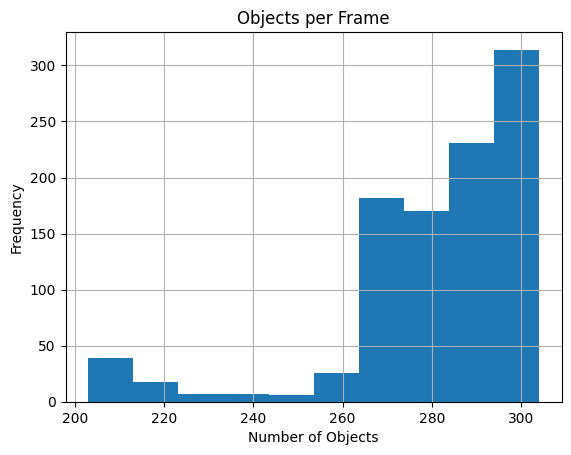

In [117]:
objects_per_frame = df.groupby(["video", "frame_id"]).size()

# Plot histogram of objects per frame
objects_per_frame.hist()
plt.title("Objects per Frame")
plt.xlabel("Number of Objects")
plt.ylabel("Frequency")
plt.show()

In [118]:
def visualize_sample(video_path, df, n_frames=5):
    import os
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    video_path = os.path.abspath(video_path)
    cap = cv2.VideoCapture(video_path)

    temp = df[df["video_path"] == video_path].copy()

    if temp.empty:
        print("This video_path is not present in df.")
        print("Passed path:", video_path)
        cap.release()
        return

    valid_frames = temp["frame_id"].unique()

    for _ in range(n_frames):
        frame_id = int(np.random.choice(valid_frames))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()

        if not ret:
            print(f"Could not read frame {frame_id}")
            continue

        anns = temp[temp["frame_id"] == frame_id]
        print(f"Frame {frame_id}: {len(anns)} annotations found")

        for _, ann in anns.iterrows():
            x, y, w, h = ann["bbox"]
            cv2.rectangle(frame, (int(x), int(y)),
                          (int(x + w), int(y + h)), (0, 255, 0), 2)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Annotated frame {frame_id}")
        plt.axis("off")
        plt.show()

    cap.release()

Frame 765: 1 annotations found


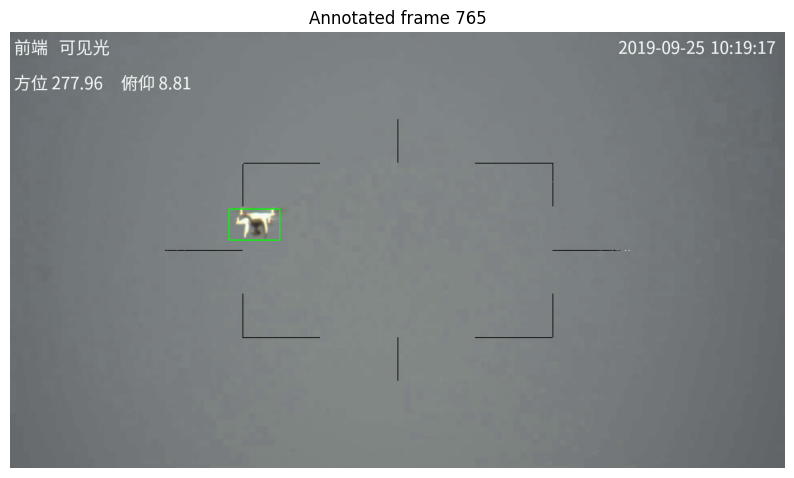

Frame 465: 1 annotations found


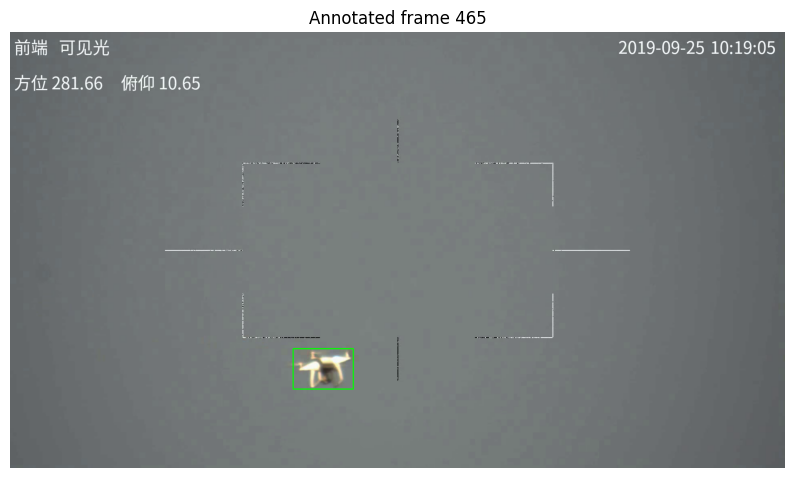

Frame 585: 1 annotations found


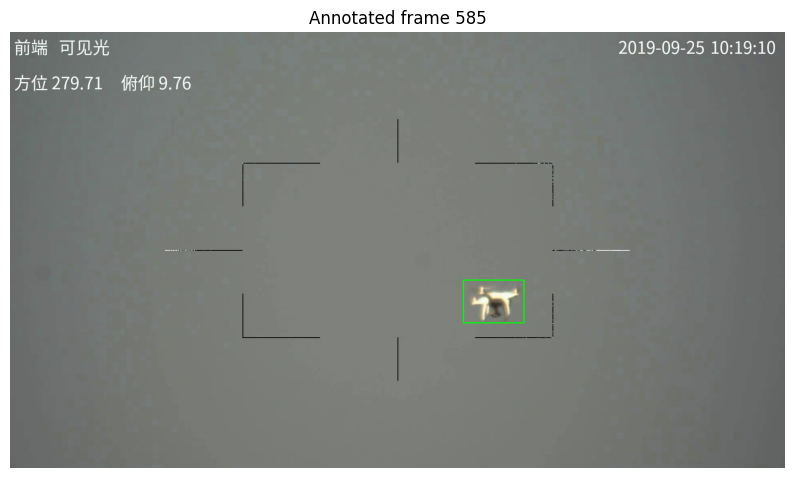

Frame 75: 1 annotations found


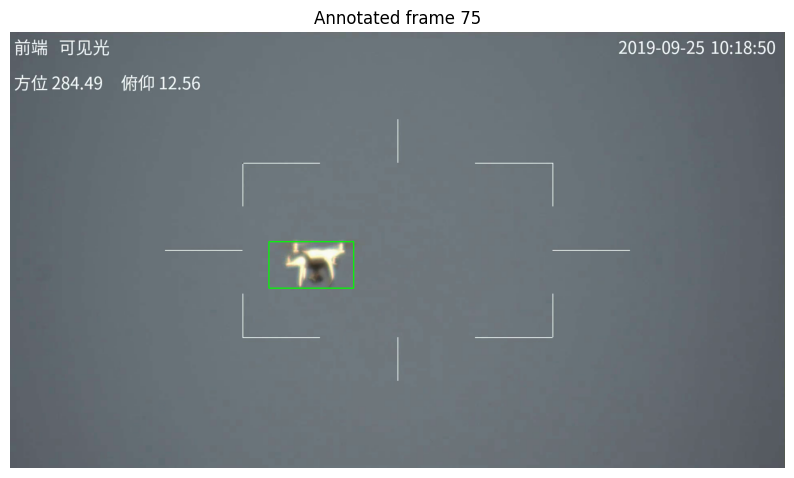

Frame 122: 1 annotations found


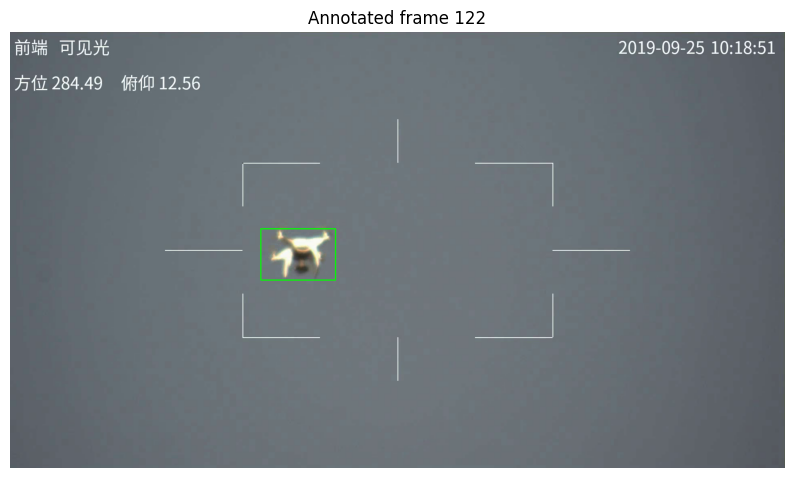

In [119]:
sample_video = df["video_path"].drop_duplicates().iloc[0]
visualize_sample(sample_video, df)

In [120]:
# Missing frame IDs
missing_frames = df["frame_id"].isnull().sum()
print(f"Missing frame annotations: {missing_frames}")

# Check for zero-size bounding boxes
zero_size_boxes = df[df["bbox_w"] <= 0]
print(f"Zero-size bounding boxes: {len(zero_size_boxes)}")

# Out-of-bound boxes (bbox width/height exceeds video width/height)
out_of_bound_boxes = df[df["bbox_w"] > df["width"]]
print(f"Out-of-bound boxes: {len(out_of_bound_boxes)}")

Missing frame annotations: 0
Zero-size bounding boxes: 151
Out-of-bound boxes: 0


In [121]:
# Check for overlap between splits
split_counts = df.groupby(["split", "video"]).size()
print(split_counts)

split  video      
test   visible.mp4     79724
train  visible.mp4    142192
val    visible.mp4     58302
dtype: int64


In [122]:
print("Avg objects per frame:", objects_per_frame.mean())
print("Small objects %:", (df["area"] < 32*32).mean())
print("Avg FPS:", df["fps"].mean())

Avg objects per frame: 280.218
Small objects %: 0.012383215924744307
Avg FPS: 20.0


## Baseline

In [123]:
import os
import json
import cv2

# Path to your dataset folder
dataset_path = "/mnt/data"  # Set the path to your dataset

# Loop through all JSON files in the dataset
for split in ["train", "val", "test"]:  # Specify which splits you have (train, val, test)
    split_path = os.path.join(dataset_path, split)

    # Loop through numbered subfolders
    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        
        if not os.path.isdir(folder_path):
            continue

        # Loop through all JSON files in each folder
        for file in os.listdir(folder_path):
            if file.endswith(".json"):  # Process only JSON files
                json_path = os.path.join(folder_path, file)
                
                # Load the JSON file
                with open(json_path) as f:
                    data = json.load(f)

                # Get image size (you may need to load or have it pre-stored)
                image_name = data["image_name"]
                image_path = os.path.join(folder_path, image_name)
                
                # Check if the image exists
                if not os.path.exists(image_path):
                    print(f"Image not found: {image_path}")
                    continue  # Skip this image if it's missing

                # Read the image to get its size (width, height)
                img = cv2.imread(image_path)
                if img is None:
                    print(f"Failed to load image: {image_path}")
                    continue  # Skip if the image can't be loaded

                img_height, img_width = img.shape[:2]

                # Prepare the text file for YOLO annotations
                label_file_path = os.path.join(folder_path, image_name.replace(".jpg", ".txt").replace(".png", ".txt"))
                
                with open(label_file_path, "w") as label_f:
                    # Loop through bounding boxes and convert them
                    for ann in data["annotations"]:
                        # Get bounding box (x, y, width, height)
                        x, y, w, h = ann["bbox"]
                        
                        # Convert to YOLO format (normalized center and size)
                        x_center = (x + w / 2) / img_width
                        y_center = (y + h / 2) / img_height
                        bbox_width = w / img_width
                        bbox_height = h / img_height

                        # Assuming "drone" is the only class (class_id = 0)
                        class_id = 0  # You can add more classes if needed

                        # Write to the text file (one line per object)
                        label_f.write(f"{class_id} {x_center} {y_center} {bbox_width} {bbox_height}\n")
                
                print(f"Converted annotations for {image_name} to YOLO format in {label_file_path}")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/mnt/data\\train'